In [18]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [19]:
# define state 

class BMIState(TypedDict):

    weight_kg: float
    height_m: float
    bmi_value: float
    category: str

In [20]:
def bmi_calc(state: BMIState) -> BMIState:
    
    wt = state['weight_kg']
    ht = state['height_m']

    bmi = wt/(ht**2)
    state['bmi_value'] = round(bmi, 2)

    return state

def bmi_category(state: BMIState) -> BMIState:

    val = "fit"
    if state['bmi_value'] > 25:
        val = "Overweight"
    elif state['bmi_value'] < 20:
        val = "Underweight"
    
    state['category'] = val
    return state

In [21]:
# define graph
graph = StateGraph(BMIState)

#node 
graph.add_node('bmi_calculation', bmi_calc)
graph.add_node('Remarks',bmi_category)

#edge 
graph.add_edge(START, 'bmi_calculation')
graph.add_edge('bmi_calculation', 'Remarks')
graph.add_edge('Remarks', END)


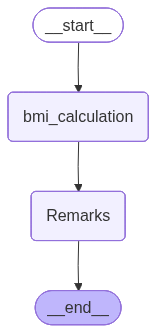

In [22]:
# compile graph 
workflow = graph.compile()
workflow

In [24]:
#execute graph
final_output = workflow.invoke({
    'weight_kg':70,
    'height_m': 1.8,
})

print(final_output)

{'weight_kg': 70, 'height_m': 1.8, 'bmi_value': 21.6, 'category': 'fit'}
